 ## **Business Problem**

Hotel booking cancellations represent a significant challenge for both City Hotel and Resort Hotel, leading to lost revenue opportunities and inefficient room utilization. Understanding the factors associated with cancellation behavior is essential for improving forecasting accuracy and revenue management strategies.

This project analyzes hotel booking data to identify key drivers of cancellations, examine customer booking patterns, and generate insights that support data-driven decision-making aimed at reducing cancellation rates and improving operational performance.

---



## **Dataset Overview**

This project uses the **Hotel Booking Demand** dataset from Kaggle, which contains booking information for two hotel types: **City Hotel** and **Resort Hotel**. The dataset includes reservation records from **July 2015 to August 2017**, covering both completed and cancelled bookings.

The dataset was originally published by Nuno Antonio, Ana Almeida, and Luis Nunes and is widely used for hotel demand and cancellation analysis.

### **Dataset Characteristics**

| Attribute | Value |
|------------|---------|
| Total Records | 119,390 bookings |
| Hotel Types | City Hotel, Resort Hotel |
| Date Range | July 2015 – August 2017 |
| Observation Unit | One hotel reservation per row |
| Target Variable | `is_canceled` (1 = Cancelled, 0 = Not Cancelled) |

### **Data Dictonary**

| Column | Description |
|----------|-------------|
| hotel | Type of hotel (City Hotel or Resort Hotel) |
| is_canceled | Whether the booking was canceled (1 = Yes, 0 = No) |
| lead_time | Number of days between booking date and arrival date |
| arrival_date_year | Year of arrival |
| arrival_date_month | Month of arrival |
| arrival_date_week_number | Week number of arrival date |
| arrival_date_day_of_month | Day of the month of arrival |
| stays_in_weekend_nights | Number of weekend nights booked |
| stays_in_week_nights | Number of weekday nights booked |
| adults | Number of adults included in the reservation |
| children | Number of children included in the reservation |
| babies | Number of babies included in the reservation |
| meal | Type of meal package booked |
| country | Country of origin of the guest |
| market_segment | Market segment through which the booking was made |
| distribution_channel | Booking distribution channel |
| is_repeated_guest | Whether the customer is a repeat guest (1 = Yes, 0 = No) |
| previous_cancellations | Number of previous bookings canceled by the customer |
| previous_bookings_not_canceled | Number of previous bookings not canceled by the customer |
| reserved_room_type | Room type originally reserved |
| assigned_room_type | Room type assigned at check-in |
| booking_changes | Number of booking modifications made before arrival |
| deposit_type | Type of deposit made for the booking |
| agent | Travel agency identifier responsible for the booking |
| company | Company identifier responsible for the booking |
| days_in_waiting_list | Number of days the booking remained on the waiting list |
| customer_type | Type of customer (Transient, Contract, Group, etc.) |
| adr | Average Daily Rate (average revenue per occupied room per day) |
| required_car_parking_spaces | Number of parking spaces requested |
| total_of_special_requests | Number of special requests made by the guest |
| reservation_status | Final booking status (Check-Out, Canceled, No-Show) |
| reservation_status_date | Date when the reservation status was last updated |


All personally identifiable information (PII) has been removed from the dataset to protect customer privacy.



### **Source**

Kaggle: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-

---


## **Import Libraries & Load Dataset**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('./hotel_bookings.csv')

## **Exploratory Data Analysis**

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [9]:
df.shape

(119390, 32)

In [10]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

### **Check Datatype**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [ ]:
## Changing the data type of 'reservation_status_date' to datetime for better analysis.
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  str           
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  str           
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119386 non-null  float64       
 11

### **Check the number of unique values of each column**

In [18]:
df.describe(include='str')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


### **Check various categories present in the different categorical columns**


In [188]:
for col in df.describe(include='string').columns:
    print(f"Unique values in '{col}': {df[col].unique()}")
    print('----')

Unique values in 'hotel': <StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
----
Unique values in 'arrival_date_month': <StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str
----
Unique values in 'meal': <StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
----
Unique values in 'country': <StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str
----
Unique values in 'market_segment': <StringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str
----
Unique values in 'distribution_channel': <StringArray>
['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS']
Length: 5, dtype: s

## **Data preparation**

### **Missing value**

In [25]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [ ]:
## Dropping columns with high percentage of missing values, and those that are not relevant to the analysis.
df.drop(['company','agent'], axis=1, inplace=True)

In [28]:
df.isnull().sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            4
babies                              0
meal                                0
country                           488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
days_in_waiting_list                0
customer_type                       0
adr                                 0
required_car

### **Statistics of the dataset**

In [29]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363,2016-07-30 00:24:47.883407
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000,2016-02-01 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000,2016-08-07 00:00:00
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-08 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798,NaN


In [ ]:
## Checking for outliers in the 'adr' column (Average Daily Rate)
df.loc[df['adr'] > 5000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,A,1,Non Refund,0,Transient,5400.0,0,0,Canceled,2016-02-19


In [ ]:
## Removing outliers in the 'adr' column
df = df[df['adr'] < 5000]

In [35]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119385.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389
mean,0.370411,104.011994,2016.156555,27.165292,15.798164,0.927606,2.500314,1.856402,0.103891,0.007949,0.031912,0.087119,0.137098,0.221118,2.321169,101.786744,0.062518,0.571368,2016-07-30 00:26:45.132801
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000,2016-02-01 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.560000,0.000000,0.000000,2016-08-07 00:00:00
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-08 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.482917,106.863358,0.707479,13.605134,8.780826,0.998614,1.908289,0.579263,0.398563,0.097437,0.175768,0.844340,1.497443,0.652304,17.594793,48.153554,0.245292,0.792800,NaN


## **Data Analysis and Visualization**

In [ ]:
# Calculate cancellation percentages
cancellation_percentage = (df['is_canceled'].value_counts(normalize=True) * 100)
print(cancellation_percentage)


is_canceled
0    62.958899
1    37.041101
Name: proportion, dtype: float64


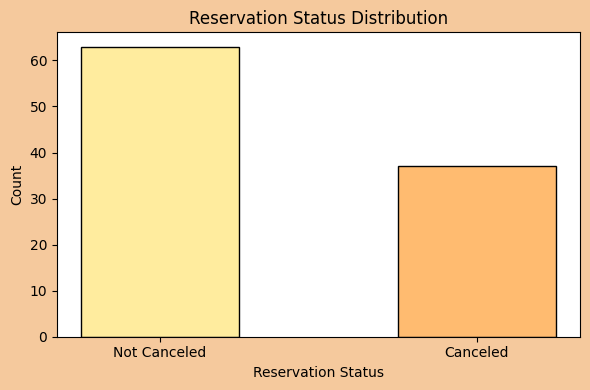

In [56]:
# Plot bar chart
plt.figure(figsize=(6,4),facecolor ='#F5C99D') #set background color
plt.title('Reservation Status Distribution') #set title
plt.bar(['Not Canceled', 'Canceled'], cancellation_percentage, color=['#FFEC9E', '#FFBB70'], width=0.5,edgecolor='black')
plt.xlabel('Reservation Status') #set x-axis label
plt.ylabel('Count') #set y-axis label  
plt.tight_layout()
plt.show()

#### The  bar graph shows the cancellation and non-cancellation percentages for reservations. It shows that there are 63% of reservation remains not cancel. However, 37% of clients have chosen to cancel their reservations, and this causes an impact on the hotels' revenue.
---

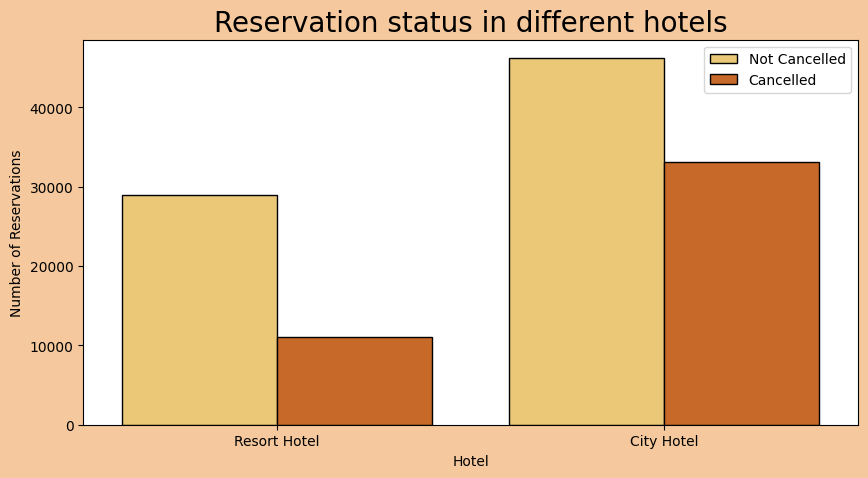

In [187]:
palette1 = sns.color_palette("YlOrBr", n_colors=2)

plt.figure(figsize=(10, 5), facecolor='#F5C99D')

ax1 = sns.countplot( x='hotel', hue='is_canceled',data=df,palette=palette1, edgecolor='black')

ax1.legend(bbox_to_anchor=(1, 1))

plt.title('Reservation status in different hotels', size=20, color='Black')
plt.xlabel('Hotel', color='Black')
plt.ylabel('Number of Reservations', color='Black')

plt.legend(['Not Cancelled', 'Cancelled'])

plt.tight_layout
plt.show()

#### According to above graph, City Hotels have more booking. Hypothetically, the reason can be the higher price in resort hotel category and also customer tend to stay longer in resort which result lower turn over compare to City Hotels
---

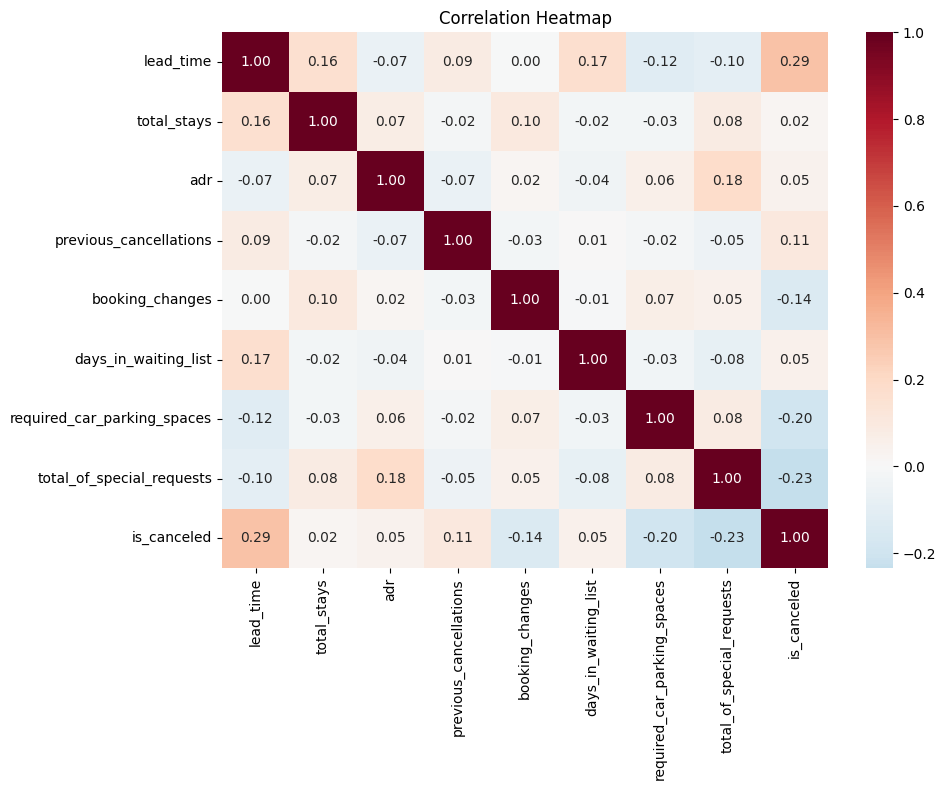

In [117]:
#Calculate total stays
df['total_stays'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights'] 

# Select numerical variables
corr_cols = [
    'lead_time',
    'total_stays',
    'adr',
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'is_canceled'
]

# Calculate correlation matrix
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10,8))

# Create a heatmap 
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#### The correlation heatmap provides an overview of the relationships between booking attributes and cancellation behavior. Lead time shows the strongest positive association with cancellation (r = 0.29), while the number of special requests (r = -0.23) and required parking spaces (r = -0.20) are negatively associated with cancellation. These findings highlight potential predictors of cancellation but do not imply causation.
---

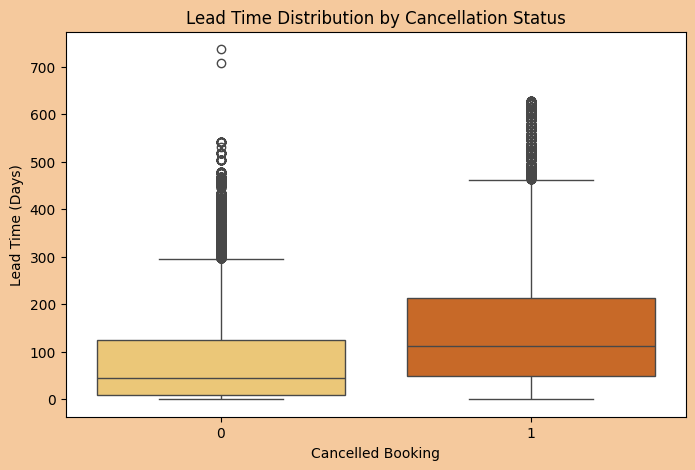

In [201]:
plt.figure(figsize=(8,5), facecolor='#F5C99D')

sns.boxplot( data=df, x='is_canceled', y='lead_time', palette="YlOrBr", hue='is_canceled', legend=False)

plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Cancelled Booking')
plt.ylabel('Lead Time (Days)')

plt.show()

#### Cancelled bookings have a noticeably higher median lead time and greater variability than non-cancelled bookings, supporting the hypothesis that bookings made further in advance are more likely to be cancelled.
---

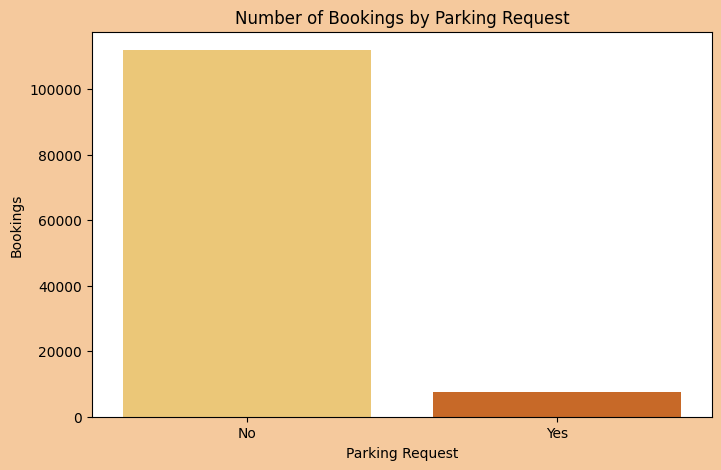

  parking_request   count
0              No  111973
1             Yes    7416


In [209]:
df['parking_request'] = np.where(df['required_car_parking_spaces'] > 0, 'Yes', 'No')

parking_request_count = df['parking_request'].value_counts().reset_index()
parking_request_count.columns = ['parking_request', 'count']


plt.figure(figsize=(8,5), facecolor='#F5C99D')
sns.barplot(data=parking_request_count, x='parking_request', y='count', palette='YlOrBr', hue='parking_request', legend=False)

plt.title('Number of Bookings by Parking Request')
plt.xlabel('Parking Request')
plt.ylabel('Bookings')

plt.show()

print(parking_request_count)






#### Guests requesting parking spaces exhibit substantially lower cancellation rates than guests without parking requests. This suggests that bookings involving parking requirements may represent more committed travel plans.
---

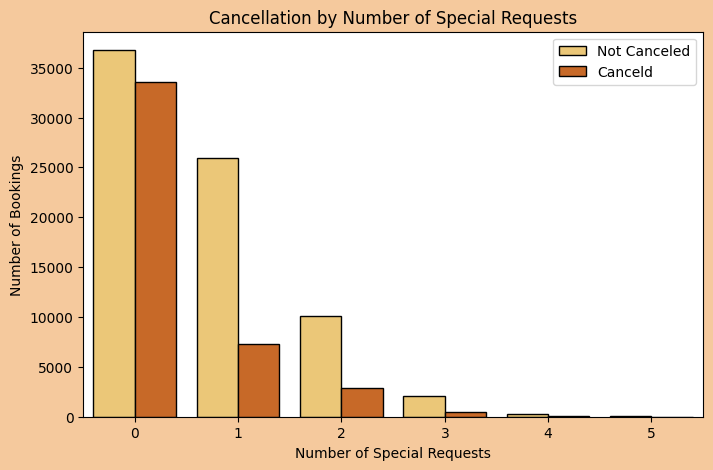

In [186]:
total_stays = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['stay_bucket'] = pd.cut(
    total_stays,
    bins=[0, 2, 5, 10, 20, 50],
    labels=['1-2', '3-5', '6-10', '11-20', '20+']
)

cancel_rate = (
    df.groupby('stay_bucket')['is_canceled']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5),facecolor="#F5C99D")

sns.countplot(data=df,palette="YlOrBr",x='total_of_special_requests', hue='is_canceled', edgecolor='black')


plt.title('Cancellation by Number of Special Requests')
plt.ylabel('Number of Bookings')
plt.xlabel('Number of Special Requests')
plt.legend(['Not Canceled','Canceld'])

plt.show()

#### The chart indicates a negative relationship between special requests and cancellation behavior. Guests with multiple special requests are less likely to cancel their reservations, which result from a higher level of booking commitment by having engagement with the planned stay.
---

In [175]:
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24218
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [176]:
df ['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.473050
Offline TA/TO    0.202850
Groups           0.165937
Direct           0.105588
Corporate        0.044351
Complementary    0.006223
Aviation         0.001985
Undefined        0.000017
Name: proportion, dtype: float64

In [ ]:
cancelled_bookings = df[df['is_canceled'] == 1]
cancelled_bookings ['market_segment'].value_counts()


market_segment
Online TA        20739
Groups           12097
Offline TA/TO     8310
Direct            1934
Corporate          992
Complementary       97
Aviation            52
Undefined            2
Name: count, dtype: int64

In [173]:
cancelled_bookings = df[df['is_canceled'] == 1]
cancelled_bookings ['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.468964
Groups           0.273545
Offline TA/TO    0.187911
Direct           0.043733
Corporate        0.022432
Complementary    0.002193
Aviation         0.001176
Undefined        0.000045
Name: proportion, dtype: float64

#### Online TA accounts for nearly half of all bookings and cancellations, reflecting its dominant share of reservation volume. However, group bookings appear disproportionately represented among cancellations, while direct bookings contribute a relatively small share of cancelled reservations, suggesting differences in cancellation behavior across market segments.
---

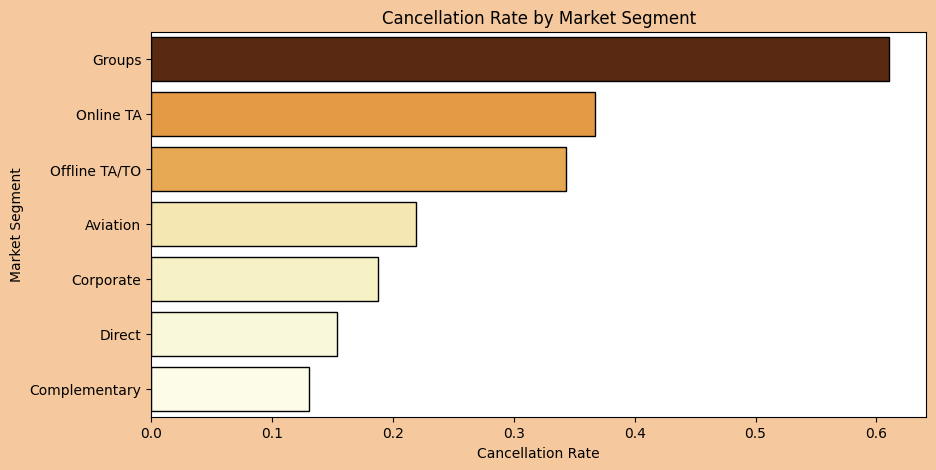

  market_segment  is_canceled
0      Undefined     1.000000
1         Groups     0.610620
2      Online TA     0.367211
3  Offline TA/TO     0.343133
4       Aviation     0.219409
5      Corporate     0.187347
6         Direct     0.153419
7  Complementary     0.130552


In [210]:
cancel_rate_segment = (
    df.groupby('market_segment')['is_canceled']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

#Create a bar plot to visualize cancellation rates by market segment (EXCLUDE 'Undefined' segment)
plt.figure(figsize=(10,5), facecolor='#F5C99D')

sns.barplot( data=cancel_rate_segment[1:],  x='is_canceled', y='market_segment', palette='YlOrBr', hue='is_canceled', legend=False, edgecolor='black')

plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation Rate')
plt.ylabel('Market Segment')

plt.show()

print(cancel_rate_segment)

#### In order to see a clearer view, the cancellation rate per segment is performed. 
#### Imprortant note is Undefined = 1.00 is based on only 2 bookings from your earlier output. With such a tiny sample size, it's not meaningful and should be excluded from interpretation.
#### Market segment analysis reveals  differences in cancellation behavior. Group bookings exhibit the highest cancellation rate (61.1%), followed by Online TA (36.7%) and Offline TA/TO (34.3%). In contrast, Direct bookings show a significantly lower cancellation rate (15.3%), suggesting stronger booking commitment among customers who reserve directly with the hotel.

---

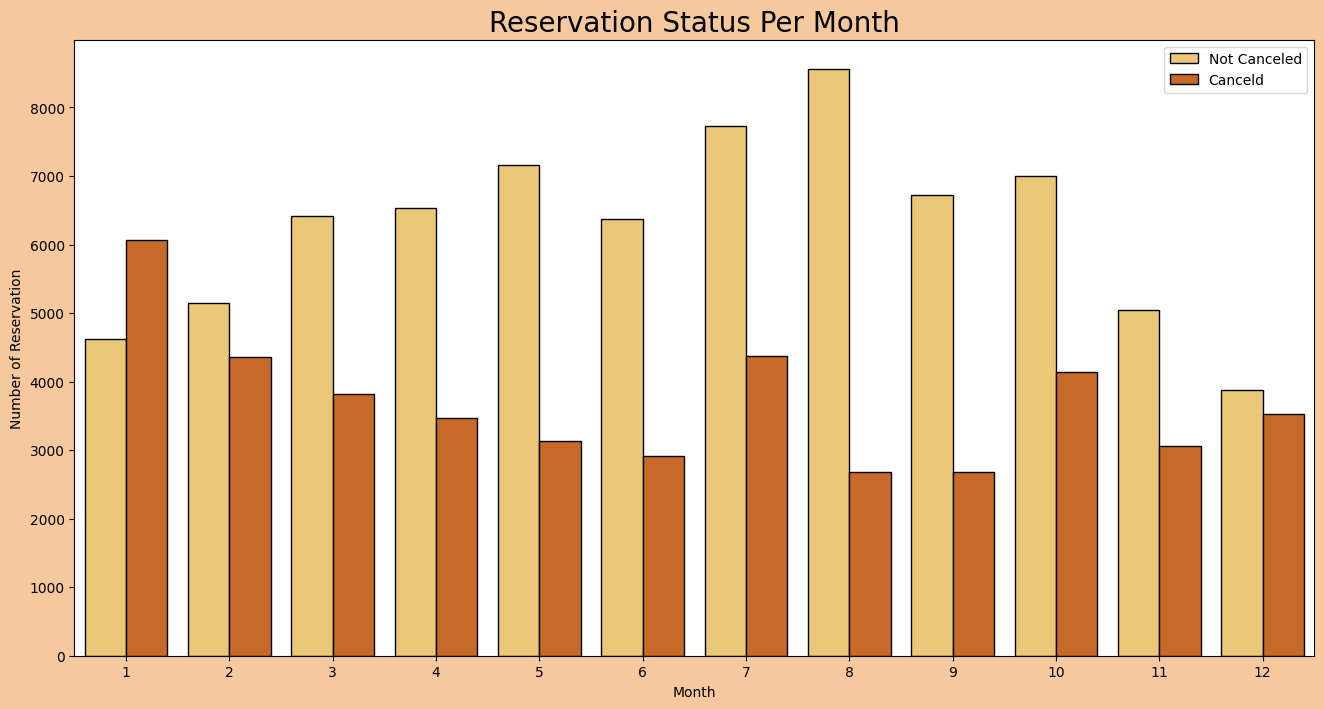

In [185]:
df['month']=df['reservation_status_date'].dt.month
plt.figure(figsize=(16,8), facecolor='#F5C99D')
ax1 = sns.countplot(x='month', hue='is_canceled', data= df, palette = "YlOrBr", edgecolor='black')
legend_lebels,_ = ax1.get_legend_handles_labels()
plt.title('Reservation Status Per Month', size = 20)
plt.xlabel('Month')
plt.ylabel('Number of Reservation')
plt.legend(['Not Canceled','Canceld'])
plt.show()

#### The bar chart show the months with the highest and lowest total of reservation based on their status. Reservation demand peaks during the summer season, with August generating the highest volume of completed bookings. This pattern suggests that hotels may experience increased occupancy and revenue opportunities during peak travel periods.

## **Business Recommendation**


### **1. Optimize Pricing During Peak Seasons**

Reservation demand peaks during the summer months, particularly in August. Hotels should consider implementing dynamic pricing strategies during high-demand periods to maximize occupancy and revenue.

---

### **2. Develop Strategies to Mitigate Cancellations During High-Risk Periods**

January exhibits the highest volume of cancelled reservations. Hotels may consider offering:

 - Early-bird discounts
 - Flexible rebooking options
 - Targeted promotional campaigns

 These initiatives can help maintain reservation demand and reduce potential revenue loss during this period.

---

### **3. Encourage Direct Bookings**

 Direct bookings demonstrate significantly lower cancellation rates than bookings made through intermediaries. Hotels should strengthen:

 - Loyalty programs
 - Member-exclusive offers
 - Direct-booking incentives

 These strategies can increase customer commitment and reduce cancellation risk.

---

 ### **4. Improve Customer Engagement for Long Lead-Time Reservations**

 Lead time shows the strongest positive association with cancellation behavior. Hotels can implement:

 - Automated follow-up communications
 - Booking reminders
 - Personalized offers

 These engagement strategies can help maintain customer interest and reduce the likelihood of cancellation among guests who book well in advance.

---
